In [1]:
from google.colab import files
uploaded = files.upload()


Saving Bengaluru_House_Data.csv to Bengaluru_House_Data.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.dropna(inplace=True)

df['bath'] = df['bath'].astype(int)
df['size'] = df['size'].astype(str).str.extract(r'(\d+)').astype(float)
df['price'] = df['price'] * 100000
df['location'] = df['location'].fillna("Other")


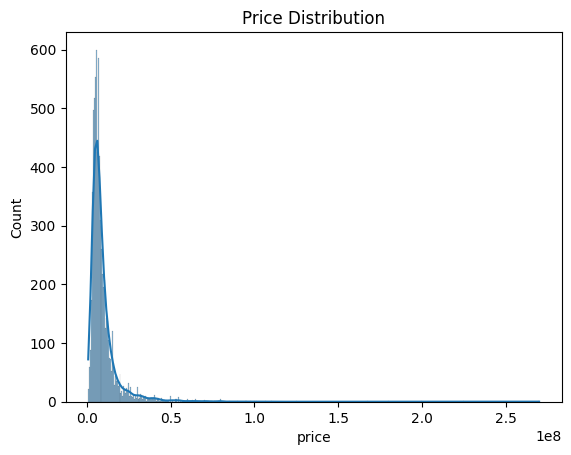

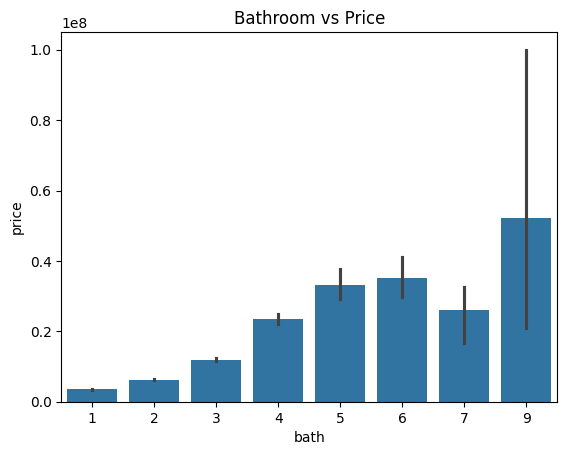

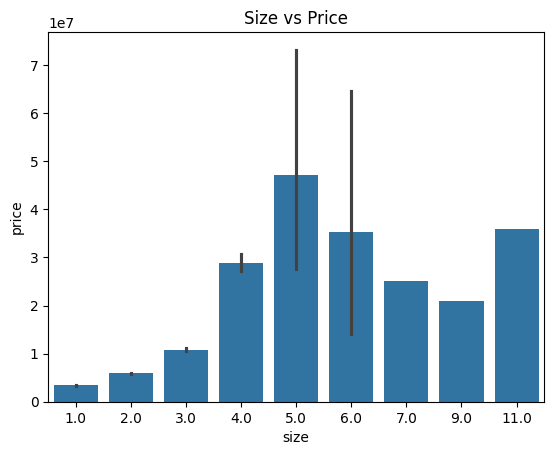

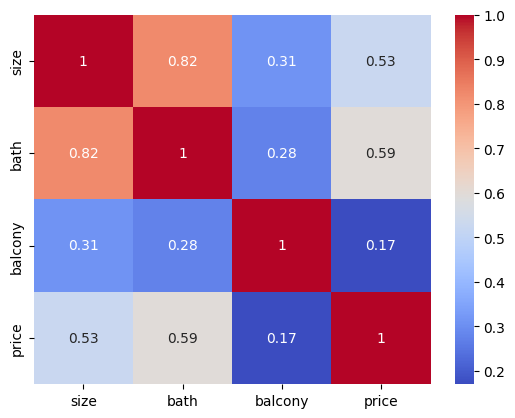

In [4]:
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

sns.barplot(x='bath', y='price', data=df)
plt.title("Bathroom vs Price")
plt.show()

sns.barplot(x='size', y='price', data=df)
plt.title("Size vs Price")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [5]:
def convert_sqft(x):
    try:
        # Case: Range like "1200 - 1500"
        if "-" in x:
            parts = x.split("-")
            return (float(parts[0]) + float(parts[1])) / 2

        # Case: Pure Number
        return float(x)

    except:
        return None   # For values like "34.46Sq. Meter"

# Apply conversion
df['total_sqft'] = df['total_sqft'].astype(str).apply(convert_sqft)

# Remove rows where sqft could not convert
df.dropna(subset=['total_sqft'], inplace=True)


In [6]:
df['price_per_sqft'] = df['price'] / df['total_sqft']

data = df[['location','size','bath','price']]
data = pd.get_dummies(data, drop_first=True)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = data.drop('price', axis=1)
y = data['price']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=10)

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)


In [8]:
print("R2 Score:", r2_score(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))


R2 Score: 0.5475859307177806
RMSE: 7588632.358692277
